In [1]:
from cluster_functions import lowess
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import astropy.units as u
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.ticker import FormatStrFormatter
import seaborn as sns
palette = 'viridis'
font = {'color':  'black', 'weight': 'normal','size': 14}
font_cb = {'color':  'black', 'weight': 'normal','size': 12}
labelsize = 12

In [2]:
df = pd.read_csv('Dados/results.csv', index_col = 'Cluster')
data = pd.read_csv('Dados/data.csv', index_col ='Cluster')

In [3]:
df.FeH.describe()

count    771.000000
mean      -0.035634
std        0.107249
min       -0.373000
25%       -0.113500
50%       -0.036000
75%        0.032000
max        0.426000
Name: FeH, dtype: float64

In [3]:
def plot_panel(ax, X, Y, Yerr, xlabel, ylabel=None, ylim = True, show_legend=False):
    order = np.argsort(X)
    y_sm, y_std = lowess(X,Y, f=0.3)
    ax.plot(X[order], y_sm[order], color='red', label='LOWESS')
    ax.fill_between(X[order],
                np.where((y_sm[order] - 1.96*y_std[order])<0, 0 , y_sm[order] - 1.96*y_std[order]),
                np.where((y_sm[order] + 1.96*y_std[order])>1, 1 , y_sm[order] + 1.96*y_std[order]), 
                alpha=0.5, label='LOWESS uncertainty')

    sc = ax.scatter(
        X,
        Y,
        c=df['Av'],
        cmap=palette,
        s=18
    )

    subconjuntos = np.array_split(df.sort_values(by=X.name), 5)

    x, y = [], []
    x_err, y_err = [], []

    for conjunto in subconjuntos:
        x.append(conjunto[X.name].mean())
        y.append(conjunto[Y.name].mean())
        y_err.append(conjunto[Y.name].std())
    
    ax.errorbar(x,y,yerr = y_err, fmt='o',capsize=3, c='red', alpha=0.6, ms=5, ecolor = 'k', mec='k', mew=0.5,)

    ax.set_xlabel(xlabel, fontdict=font)
    if ylabel:
        ax.set_ylabel(ylabel, fontdict=font)

    if show_legend:
        ax.legend(frameon=False, loc = 'upper left')
        # Ticks
    ax.tick_params(direction='in', labelsize=labelsize, labelleft=True, labelbottom = True)

    if ylim:
        delta = (Y.max() - Y.min()) * 0.1
        ax.set_ylim(max(0, Y.min() - delta), min(1, Y.max() + delta))


    return sc

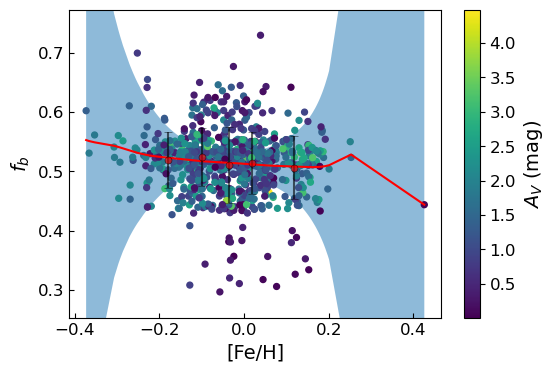

In [8]:
fig, ax = plt.subplots(figsize=(6, 4),
    gridspec_kw={'hspace': 0.2, 'wspace': 0.5})

sc = plot_panel(
    ax=ax,
    X=df.FeH,
    Y=df.bin_frac_corr,
    Yerr=df.e_bin_frac,
    xlabel='[Fe/H]',
    ylabel=r'$f_b$',
)


cbar = fig.colorbar(sc, ax=ax,)
cbar.set_label(r'$A_V$ (mag)', fontdict=font)
cbar.ax.xaxis.set_label_position('top') 
cbar.ax.tick_params(labelsize=labelsize)

plt.savefig('Figures/dist_fb_metalicidade.png', bbox_inches='tight', dpi=300)
plt.show()

In [242]:
data[(data.mass<1)  & (data.q>0.5) ][['comp_mass', 'q']].describe()

,comp_mass,q
count,19895.000000,19895.000000
mean,0.567750,0.774763
std,0.183356,0.121139
min,0.101436,0.500016
25%,0.432898,0.682049
50%,0.583277,0.804150
75%,0.710434,0.878069
max,0.953456,0.978312


In [243]:
data[(data.mass>=1) & (data.mass<8) & (data.q>0.5) ][['comp_mass', 'q']].describe()

,comp_mass,q
count,40895.000000,40895.000000
mean,1.229463,0.746049
std,0.607007,0.136690
min,0.504218,0.500012
25%,0.898940,0.624855
50%,1.078399,0.744551
75%,1.398927,0.876381
max,7.354812,0.990220


In [240]:
data[(data.mass>=8)  & (data.q>0.5) ][['comp_mass', 'q']].describe()

,comp_mass,q
count,234.000000,234.000000
mean,9.129011,0.771397
std,4.226646,0.146179
min,4.164521,0.504652
25%,6.629112,0.639647
50%,8.332218,0.783153
75%,10.097888,0.907350
max,30.425772,0.992268


In [241]:
data[(data.mass>=8)  & (data.q>0.) ][['comp_mass', 'q']].describe()

,comp_mass,q
count,508.000000,508.000000
mean,6.256457,0.517077
std,4.199190,0.273137
min,0.101046,0.005507
25%,3.872261,0.344871
50%,5.532932,0.446758
75%,8.012685,0.754750
max,30.425772,0.992268
